# v04 — Report Summary

범위: v01~v03 핵심 수치와 해석 요약.

In [1]:
from pathlib import Path
import json
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'src' / 'team2_surrender').exists()
)
os.chdir(ROOT)
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from IPython.display import display, Markdown, Image
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from team2_surrender.modeling import FEATURE_COLUMNS, TARGET_COLUMN, GROUP_COLUMN, make_group_split

RUN_ID = 'riot-scale-2600'
DATA_PATH = ROOT / 'data' / 'processed' / 'riot' / f'{RUN_ID}_team_features.csv'
VALIDATION_PATH = ROOT / 'data' / 'processed' / 'riot' / f'{RUN_ID}_team_features_validation_strict.json'
METRICS_PATH = ROOT / 'outputs' / 'metrics' / f'{RUN_ID}_model_comparison.json'
FIGURE_DIR = ROOT / 'reports' / 'figures' / RUN_ID
MODEL_DIR = ROOT / 'models' / RUN_ID
UPLOAD_VERIFICATION_PATH = ROOT / 'outputs' / 'verification' / f'supabase_upload_{RUN_ID}.json'

REQUIRED_PATHS = [DATA_PATH, VALIDATION_PATH, METRICS_PATH, FIGURE_DIR, MODEL_DIR, UPLOAD_VERIFICATION_PATH]

for path in REQUIRED_PATHS:
    print(f'{path.relative_to(ROOT)} -> {path.exists()}')

missing_paths = [path for path in REQUIRED_PATHS if not path.exists()]
if missing_paths:
    missing_text = '\n'.join(str(path.relative_to(ROOT)) for path in missing_paths)
    raise FileNotFoundError(
        'Missing required analysis artifacts:\n'
        f'{missing_text}\n\n'
        'Run: python scripts/prepare_jupyter_analysis_artifacts.py'
    )

data/processed/riot/riot-scale-2600_team_features.csv -> True
data/processed/riot/riot-scale-2600_team_features_validation_strict.json -> True
outputs/metrics/riot-scale-2600_model_comparison.json -> True
reports/figures/riot-scale-2600 -> True
models/riot-scale-2600 -> True
outputs/verification/supabase_upload_riot-scale-2600.json -> True


In [2]:
df = pd.read_csv(DATA_PATH)
y = df[TARGET_COLUMN].astype(bool).astype(int)
print('rows:', len(df))
print('matches:', df[GROUP_COLUMN].nunique())
print('positive rows:', int(y.sum()))
print('positive rate:', round(float(y.mean()), 4))
display(df.head())

rows: 5050
matches: 2525
positive rows: 870
positive rate: 0.1723


,match_id,team_id,feature_version,team_surrendered,queue_id,game_version,game_duration_sec,collected_at,gold_diff_15,kill_diff_15,tower_diff_15,dragon_diff_15,rift_herald_diff_15,cs_diff_15,avg_level_diff_15,first_blood,first_tower,ward_placed_diff_15,ward_kill_diff_15
0,KR_8143703690,100,v1_15min,True,420,16.6.756.931,1382,2026-05-14T19:59:29+00:00,-270,-6,1,-1,0,8,-0.4,1,1,-7,2
1,KR_8143703690,200,v1_15min,False,420,16.6.756.931,1382,2026-05-14T19:59:29+00:00,270,6,-1,1,0,-8,0.4,-1,-1,7,-2
2,KR_8143357958,100,v1_15min,False,420,16.6.756.931,2232,2026-05-14T19:59:29+00:00,2064,3,0,-2,0,9,0.2,-1,-1,1,-2
3,KR_8143357958,200,v1_15min,False,420,16.6.756.931,2232,2026-05-14T19:59:29+00:00,-2064,-3,0,2,0,-9,-0.2,1,1,-1,2
4,KR_8143287893,100,v1_15min,False,420,16.6.756.931,1473,2026-05-14T19:59:29+00:00,-4374,-9,0,-2,0,-74,-0.6,-1,0,1,-6


## 1. Problem definition

Riot Ranked Solo/Duo 경기에서 15분 시점 팀 상태를 이용해, 해당 팀이 항복으로 패배할 위험을 예측함. 분석 단위는 participant가 아니라 **team-level row**임.

## 2. Data and validation summary

In [3]:
validation = json.loads(VALIDATION_PATH.read_text())
upload = json.loads(UPLOAD_VERIFICATION_PATH.read_text())
report_summary = pd.DataFrame({
    'item': ['run_id', 'matches', 'team_rows', 'positive_rows', 'positive_rate', 'supabase_upload_status'],
    'value': [
        RUN_ID,
        df[GROUP_COLUMN].nunique(),
        len(df),
        int(y.sum()),
        round(float(y.mean()), 4),
        upload.get('status'),
    ]
})
display(report_summary)

,item,value
0,run_id,riot-scale-2600
1,matches,2525
2,team_rows,5050
3,positive_rows,870
4,positive_rate,0.1723
5,supabase_upload_status,complete


## 3. Core EDA finding

,negative_mean,positive_mean,positive_minus_negative
gold_diff_15,739.053828,-3550.856322,-4289.910150
cs_diff_15,6.805024,-32.695402,-39.500426
kill_diff_15,1.269139,-6.097701,-7.366840
ward_placed_diff_15,0.294737,-1.416092,-1.710829
tower_diff_15,0.185167,-0.889655,-1.074823
ward_kill_diff_15,0.158373,-0.760920,-0.919293
dragon_diff_15,0.132057,-0.634483,-0.766540
avg_level_diff_15,0.103684,-0.498161,-0.601845


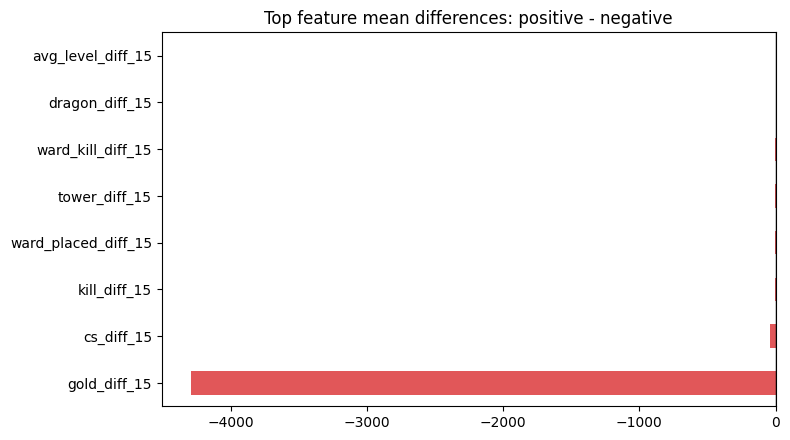

In [4]:
class_means = df.groupby(y)[FEATURE_COLUMNS].mean().T
class_means.columns = ['negative_mean', 'positive_mean']
class_means['positive_minus_negative'] = class_means['positive_mean'] - class_means['negative_mean']
top_directional = class_means.reindex(class_means['positive_minus_negative'].abs().sort_values(ascending=False).index).head(8)
display(top_directional)

fig, ax = plt.subplots(figsize=(8, 4.5))
top_directional.sort_values('positive_minus_negative')['positive_minus_negative'].plot(kind='barh', ax=ax, color='#e15759')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Top feature mean differences: positive - negative')
plt.tight_layout()
plt.show()

## 4. Model result summary

In [5]:
metrics = json.loads(METRICS_PATH.read_text())
rows = []
for model_name, splits in metrics['models'].items():
    vals = splits['test']
    rows.append({
        'model': model_name,
        'accuracy': vals['accuracy'],
        'f1': vals['f1'],
        'precision': vals['precision'],
        'recall': vals['recall'],
        'roc_auc': vals['roc_auc'],
        'pr_auc': vals['pr_auc'],
    })
model_summary = pd.DataFrame(rows).sort_values('roc_auc', ascending=False)
display(model_summary)

,model,accuracy,f1,precision,recall,roc_auc,pr_auc
2,logistic_regression,0.725743,0.493601,0.371901,0.733696,0.810105,0.494369
3,random_forest,0.833663,0.408451,0.580000,0.315217,0.785398,0.477138
1,hist_gradient_boosting,0.814851,0.304833,0.482353,0.222826,0.745210,0.386331
0,dummy_most_frequent,0.817822,0.000000,0.000000,0.000000,0.500000,0.182178


## 5. Summary

- 수집/전처리 결과: `riot-scale-2600` 실행본에서 2,525경기, 5,050개 team row 확보함.
- label: 항복으로 종료된 경기에서 패배 팀만 positive로 정의해 team-level label leakage 줄임.
- 검증: strict validation과 업로드 전 로컬 row count 검증 통과함.
- 모델: Logistic Regression이 test ROC-AUC 기준 가장 높은 성능 보임.
- 해석: 15분 시점 gold/kill/cs/tower/dragon 차이가 항복 패배 label과 관련됨.
- 한계: Emerald I 중심 데이터라 tier/generalization 편향 남음.